## Identify Customer Segments:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from preprocessor import AzdiasPreprocessor

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import set_config

import json
from joblib import load

# magic word for producing visualizations in notebook
%matplotlib inline

pd.options.display.max_rows = None
pd.options.display.max_columns = None

# So that our sklearn estimators/transformers output a pandas dataframe
set_config(transform_output="pandas")

In [2]:
# CONSTANTS
DATA_AZDIAS = 'Udacity_AZDIAS_Subset.csv'
DATA_CUSTOMERS = "Udacity_CUSTOMERS_Subset.csv"
DATA_F_SUMMARY = 'Azdias_Feature_Summary.csv'
DATA_DICT = 'data_dictionary.json'

### Step 1: Load Data:

In [3]:
df_population = pd.read_csv('population_clean.csv')
df_customer = pd.read_csv('customer_clean.csv')
scaler = load('scaler.pkl')
feature_summary = pd.read_csv(DATA_F_SUMMARY, delimiter=';')

with open(DATA_DICT, 'r') as f:
    feature_dictionary = json.load(f)


In [4]:
df_population.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,ANZ_PERSONEN,ANZ_TITEL,ARBEIT,BALLRAUM,CAMEO_DEUG_2015_2,CAMEO_DEUG_2015_3,CAMEO_DEUG_2015_4,CAMEO_DEUG_2015_5,CAMEO_DEUG_2015_6,CAMEO_DEUG_2015_7,CAMEO_DEUG_2015_8,CAMEO_DEUG_2015_9,CAMEO_LIFESTAGE,CAMEO_WEALTH,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,EWDICHTE,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,FINANZ_ANLEGER,FINANZ_HAUSBAUER,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_UNAUFFAELLIGER,FINANZ_VORSORGER,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GEBAEUDETYP_RASTER,GREEN_AVANTGARDE,HEALTH_TYP,HH_EINKOMMEN_SCORE,INNENSTADT,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,KBA13_ANZAHL_PKW,KKK,KONSUMNAEHE,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,MIN_GEBAEUDEJAHR,MOBI_REGIO,NATIONALITAET_KZ_2.0,NATIONALITAET_KZ_3.0,ONLINE_AFFINITAET,ORTSGR_KLS9,OST_WEST_KZ,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_GBZ,PLZ8_HHZ,PRAEGENDE_DECADE,PRAEGENDE_MOVEMENT,REGIOTYP,RELAT_AB,RETOURTYP_BK_S,SEMIO_DOM,SEMIO_ERL,SEMIO_FAM,SEMIO_KAEM,SEMIO_KRIT,SEMIO_KULT,SEMIO_LUST,SEMIO_MAT,SEMIO_PFLICHT,SEMIO_RAT,SEMIO_REL,SEMIO_SOZ,SEMIO_TRADV,SEMIO_VERT,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SOHO_KZ,VERS_TYP,WOHNDAUER_2008,W_KEIT_KIND_HH,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,-1.766616,0.957933,0.173054,-0.125139,0.234378,-0.060412,-0.171445,0.845269,-0.341238,-0.349292,-0.386920,-0.272896,-0.391122,-0.328993,2.162640,-0.396012,-1.249039,1.175774,-0.463801,-0.475617,-0.58412,2.486346,-0.382997,-0.547202,-0.388744,-0.243824,-0.274507,-0.392086,-0.753661,1.466048,1.339234,-1.494605,1.537983,0.958818,-1.040689,-0.078636,-0.537096,-0.033547,-0.001119,-0.027998,2.057545,-0.799725,-0.530442,1.010190,1.026614,1.701148,-1.008971,-0.965814,-0.594928,2.730470,-1.65918,0.942989,-0.791555,-1.304504,-0.439064,-0.255071,-0.375374,-0.076875,-0.121318,8.393870,-0.103924,-0.158582,-0.167513,-0.115205,-0.403178,2.486385,-0.307461,-0.319638,-0.189224,-0.19383,-0.108023,-0.155338,-0.453963,-0.383241,-1.279936,-0.294402,-0.206255,0.167005,-0.127075,0.517441,-0.256546,0.211996,0.403008,0.442407,0.574231,1.455713,1.098143,0.530442,-0.882355,0.684853,-1.685370,1.339260,-1.435418,-0.059306,-0.157563,-0.312140,-0.578196,-1.109902,-0.463834,1.518634,1.274181,0.002910,0.443126,1.288949,-1.684601,-0.743502,-0.589775,1.847335,10.854259,0.922935,0.56721,-0.730152,-0.2077,-0.739688,-0.592844,2.976005,-0.312186
1,0.200529,0.957933,0.109053,-0.125139,-0.630291,-0.060412,-0.171445,-0.986658,-0.341238,-0.349292,2.584515,-0.272896,-0.391122,-0.328993,-0.462398,-0.396012,0.766998,-0.869601,-0.463801,2.102531,-0.58412,-0.402197,-0.382997,0.034445,-0.388744,-0.243824,-0.274507,-0.392086,-0.753661,-0.570958,1.339234,-1.494605,0.864617,0.244259,-1.766963,-0.078636,-0.537096,-0.033547,-0.001119,-0.027998,-0.486016,0.283505,1.885219,1.010190,-0.267724,-0.271044,-0.298054,1.444621,0.408037,-0.464121,-0.11620,0.227973,-0.791555,1.274897,-0.439064,-0.255071,-0.375374,-0.076875,-0.121318,-0.119135,-0.103924,-0.158582,-0.167513,-0.115205,-0.403178,-0.402190,3.252447,-0.319638,-0.189224,-0.19383,-0.108023,-0.155338,-0.453963,-0.383241,0.092683,-0.294402,-0.206255,-0.476424,-0.127075,0.517441,0.786548,0.211996,-0.623023,-0.934907,0.574231,0.419647,1.098143,-1.885219,-1.435142,-0.789058,-0.310826,1.339260,0.754233,-1.626960,1.448724,1.392131,-0.578196,-0.158759,-0.463834,-0.638880,0.064249,-0.520526,-0.072090,-0.410237,-0.142572,-0.743502,1.695563,-0.541320,-0.092130,-1.083500,0.56721,-0.730152,-0.2077,-0.739688,-0.592844,2.976005,-0.312186
2,1.184102,0.957933

In [5]:
df_customer.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,ANZ_PERSONEN,ANZ_TITEL,ARBEIT,BALLRAUM,CAMEO_DEUG_2015_2,CAMEO_DEUG_2015_3,CAMEO_DEUG_2015_4,CAMEO_DEUG_2015_5,CAMEO_DEUG_2015_6,CAMEO_DEUG_2015_7,CAMEO_DEUG_2015_8,CAMEO_DEUG_2015_9,CAMEO_LIFESTAGE,CAMEO_WEALTH,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,EWDICHTE,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,FINANZ_ANLEGER,FINANZ_HAUSBAUER,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_UNAUFFAELLIGER,FINANZ_VORSORGER,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GEBAEUDETYP_RASTER,GREEN_AVANTGARDE,HEALTH_TYP,HH_EINKOMMEN_SCORE,INNENSTADT,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,KBA13_ANZAHL_PKW,KKK,KONSUMNAEHE,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,MIN_GEBAEUDEJAHR,MOBI_REGIO,NATIONALITAET_KZ_2.0,NATIONALITAET_KZ_3.0,ONLINE_AFFINITAET,ORTSGR_KLS9,OST_WEST_KZ,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_GBZ,PLZ8_HHZ,PRAEGENDE_DECADE,PRAEGENDE_MOVEMENT,REGIOTYP,RELAT_AB,RETOURTYP_BK_S,SEMIO_DOM,SEMIO_ERL,SEMIO_FAM,SEMIO_KAEM,SEMIO_KRIT,SEMIO_KULT,SEMIO_LUST,SEMIO_MAT,SEMIO_PFLICHT,SEMIO_RAT,SEMIO_REL,SEMIO_SOZ,SEMIO_TRADV,SEMIO_VERT,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SOHO_KZ,VERS_TYP,WOHNDAUER_2008,W_KEIT_KIND_HH,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,1.184102,-1.043914,-0.466953,-0.125139,0.234378,-0.060412,-2.174965,-0.528676,-0.341238,-0.349292,-0.386920,-0.272896,-0.391122,-0.328993,-0.462398,-0.396012,0.094986,-1.551393,-0.463801,-0.475617,-0.584120,2.486346,-0.382997,-1.128849,2.572389,-0.243824,-0.274507,-0.392086,-0.753661,-1.249960,-0.791347,1.409077,-1.155482,-0.470299,1.138133,-0.078636,-0.537096,-0.033547,-0.001119,-0.027998,-0.486016,0.283505,1.885219,-1.633781,-2.209230,-0.271044,0.412864,0.641143,-0.594928,-0.464121,0.65529,1.620972,-1.852828,1.274897,-0.439064,-0.255071,2.664007,-0.076875,-0.121318,-0.119135,-0.103924,-0.158582,-0.167513,-0.115205,2.480293,-0.40219,-0.307461,-0.319638,-0.189224,-0.19383,-0.108023,-0.155338,-0.453963,-0.383241,0.778992,-0.294402,-0.206255,0.167005,-1.432854,0.517441,0.786548,0.211996,-0.623023,-0.934907,1.485680,1.455713,-1.633547,-1.885219,-1.987929,-1.526014,1.063718,-1.946324,-0.888005,0.463245,-1.763850,-0.880231,-0.067417,1.267957,1.104184,-1.178258,-1.750649,-1.043961,0.958341,-1.543029,0.885447,-0.743502,-0.589775,1.847335,-0.09213,-1.083500,0.56721,0.957080,-0.207700,1.351922,-0.592844,-0.336021,-0.312186
1,1.184102,0.957933,-0.466953,-0.125139,-0.630291,-0.060412,-0.171445,1.303251,-0.341238,-0.349292,-0.386920,3.664403,-0.391122,-0.328993,-0.462398,-0.396012,0.766998,-0.187809,2.156099,-0.475617,-0.584120,-0.402197,-0.382997,0.034445,2.572389,-0.243824,-0.274507,-0.392086,-0.753661,-1.249960,0.629041,1.409077,-1.155482,0.958818,1.138133,-0.078636,-0.537096,-0.033547,-0.001119,-0.027998,2.057545,-0.799725,1.885219,-0.311795,-2.209230,-1.750188,0.412864,0.641143,-0.594928,-0.464121,-0.11620,-0.566806,0.269717,-1.304504,-0.439064,-0.255071,-0.375374,-0.076875,-0.121318,-0.119135,-0.103924,-0.158582,-0.167513,-0.115205,2.480293,-0.40219,-0.307461,-0.319638,-0.189224,-0.19383,-0.108023,-0.155338,-0.453963,-0.383241,0.092683,-0.294402,-0.206255,-1.119853,-0.127075,0.517441,-0.256546,0.211996,1.429039,0.442407,-1.248668,-0.616420,-1.633547,-1.885219,1.328795,-0.052103,1.063718,0.244065,1.301646,-1.104409,0.913295,1.392131,-1.599754,1.267957,-0.463834,-0.099501,-1.145683,-1.567397,-1.102521,-1.543029,-0.656581,1.344987,-0.589775,-0.541320,-0.09213,0.922935,0.56721,0.957080,-0.207700,1.351922,-0.592844,-0.336021,-0.312186
2,1.184102,-1

### Discussion 2.1: Apply Feature Scaling

We used an imputer to replace NaN values and then a StandardScaler() to scale all the data. As can be seen in the summary above, mean ≈ 0 and STD ≈ 1, which verifies our data is properly scaled.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

#### Step 2.2.1: Use PCA to Apply Principal Component Analysis:

We first start by applying PCA without any parameters, so all components are computed:

In [6]:
# Apply PCA to the data.
# Check number of components that is at least half the number of features
# We keep as reference to compare later
n_comps = int(df_population.shape[1] / 2)
print(f"Number of components: {n_comps}")

# PCA without parameters
pca = PCA()
X_pca = pca.fit_transform(df_population)

Number of components: 58


Next, we set our threshold:

In [7]:
# Set our explained variance threshold
VARIANCE_THRESHOLD = 90

Next, we plot:

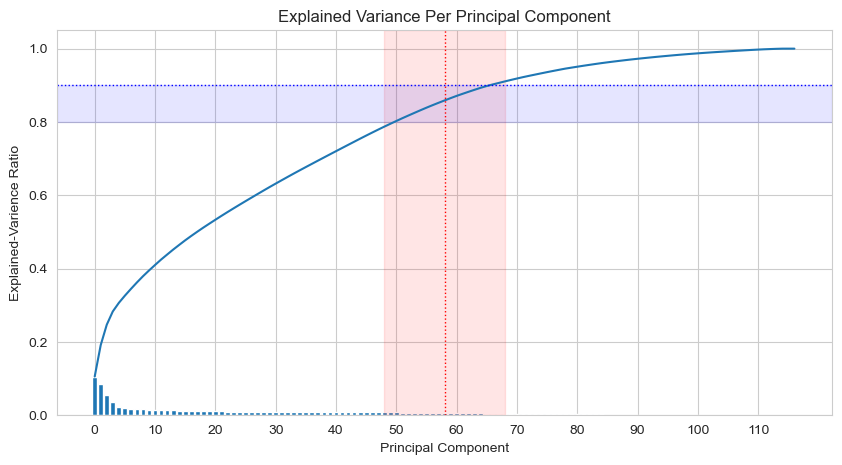

In [8]:
# Get the indexes
n_components = len(pca.explained_variance_ratio_)
component_idxs = np.arange(n_components)

# Get the explained variance ratios
variance_ratios = pca.explained_variance_ratio_

plt.figure(figsize=(10, 5))

# Get the cumulative sums
cumulative_variance = np.cumsum(variance_ratios)

# Scree Plot:
plt.bar(component_idxs, variance_ratios)
plt.plot(component_idxs, cumulative_variance)

plt.axvline(x=n_comps, linestyle=':', linewidth=1, color='r')  # Approx. N_components calculated above
plt.axvspan(n_comps - 10, n_comps + 10, alpha=0.10, color='r') # Shade the region of +/- 10 components

plt.axhline(y=VARIANCE_THRESHOLD / 100, linestyle=':', linewidth=1, color='b')  # Our Threshold
plt.axhspan(.80, .90, alpha=0.10, color='b') # Shade the of 80-90% explained variance ratio (our goal)

plt.xlabel("Principal Component")
plt.xticks(np.arange(0, n_comps * 2, 10))

plt.ylabel("Explained-Varience Ratio")
plt.title('Explained Variance Per Principal Component')
plt.show()

So, as we can see, for retaining 80-90% of information from the original data, dimensionally reduce to 85 to 105 components .

In [9]:
# Determine number of components to reach 85% variance
# Chose 85% because we want to retain 80-90% of the information from the original data
n_components = 0

# iterate over the cumulative variances
for n in range(len(cumulative_variance)):
    # Stop when we reach 85 and print the value
    if cumulative_variance[n] * 100 >= VARIANCE_THRESHOLD:
        n_components = n
        break

print(f"Number of components to reach at least {VARIANCE_THRESHOLD}% variance: {n_components}")

Number of components to reach at least 90% variance: 66


And thus, we will reduce to 96 components. We re-apply PCA to get a final model with the 96 components:

In [10]:
# Re-apply PCA to the data while selecting for number of components to retain.
# Use random_state=42 to ensure reproducible results
pca_final = PCA(n_components=n_components, random_state=42)
X_pca = pca_final.fit_transform(df_population)
X_pca.head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15,pca16,pca17,pca18,pca19,pca20,pca21,pca22,pca23,pca24,pca25,pca26,pca27,pca28,pca29,pca30,pca31,pca32,pca33,pca34,pca35,pca36,pca37,pca38,pca39,pca40,pca41,pca42,pca43,pca44,pca45,pca46,pca47,pca48,pca49,pca50,pca51,pca52,pca53,pca54,pca55,pca56,pca57,pca58,pca59,pca60,pca61,pca62,pca63,pca64,pca65
0,-4.986305,-2.389375,2.972750,-0.062877,1.562828,1.778320,-0.210640,2.818901,-1.176677,0.010183,-2.318323,0.738614,-0.092567,-0.392214,1.005106,-1.346983,-0.814535,-0.553121,-1.494871,-3.617488,0.841998,1.234174,1.490014,-0.642858,2.368485,-1.137623,0.263809,-0.412139,-1.024604,0.505886,-0.168353,-2.322585,-2.177067,1.424739,1.591297,9.370785,-1.814913,2.395940,4.613330,0.723801,-0.615042,-0.626898,-0.150704,0.226470,2.119437,-2.576419,-3.432296,-2.835211,-2.519100,-0.441073,-1.162524,-1.099184,1.502107,0.715884,1.030877,-0.031824,-0.866499,-1.990386,1.610230,2.215105,-1.280418,1.863387,0.049167,-0.364466,0.552492,-0.169353
1,0.507493,-0.416331,2.992889,2.563174,2.257768,-1.114957,-0.482449,0.375127,-0.394786,-0.257899,0.644180,0.870543,-0.943927,0.919327,-0.105968,-1.816299,-2.677364,-0.036502,-0.643405,1.791531,0.251398,-0.095869,-0.338086,-0.504045,-0.253457,0.133586,2.693228,-0.831693,-1.566318,-0.618432,1.196401,0.245859,-0.752231,-0.818277,-0.522953,-1.059024,0.471190,0.551014,0.256956,0.165755,-0.833383,-0.130729,-0.087500,0.338622,0.511952,-2.094498,-0.219077,0.615104,0.315487,0.606630,1.597047,-0.590053,0.829746,-0.010790,-0.406986,1.029836,-0.175651,-0.420992,0.727364,-0.338167,0.863370,-0.216066,1.231804,-1.348482,0.421307,1.189308
2,4.529719,1.191672,0.879933,-1.767899,-0.011387,0.041389,-0.605032,-2.083968,0.372510,1.293628,-0.618590,0.228982,0.572054,-0.982158,-0.108750,0.783911,-0.003399,1.453677,-0.759382,-0.895047,-1.241569,-0.290105,-0.102374,-0.309144,-0.711632,0.611923,0.047001,0.004627,0.846915,1.796941,-0.432636,0.590337,0.615545,0.312163,0.622188,-0.710476,0.131112,0.346765,0.377683,0.121046,0.289847,0.040091,0.050680,-0.101106,-0.615390,-0.376715,-1.699604,-0.298313,0.938326,-0.041452,-0.504803,-0.533524,0.188962,0.727387,0.892423,1.176665,0.567906,0.013838,-1.231220,0.650477,0.197868,-0.524469,-0.078428,-1.193877,0.110977,-1.233227
3,-0.578114,0.631897,-3.426123,0.995795,-1.911314,-2.896348,2.952419,1.959617,-0.352759,-0.503566,2.474299,-1.444996,-0.556972,2.192898,0.576182,0.610500,-1.108684,-1.321167,0.117967,-0.115596,1.774264,1.734164,-0.648763,0.410819,0.532980,1.740195,-0.885175,1.200773,-1.435993,1.032481,0.478077,-0.476443,-0.588378,0.012352,-0.649377,-0.286798,0.398310,-0.001916,-0.448714,0.342158,-0.205624,0.021776,-0.018586,-0.019021,0.099164,-0.297805,0.124559,1.010707,-0.150646,0.323919,-0.116181,-0.676435,1.010878,-0.943277,-0.725359,1.492204,0.231844,-0.921956,0.577418,0.717722,1.333892,-0.656205,0.338521,-0.753959,0.609551,0.754434
4,0.605613,-1.003456,1.302572,-2.771966,3.567053,-1.224377,0.995069,0.792821,1.667648,0.529979,-1.988140,-1.629707,-0.064545,-0.282768,-1.082266,-0.041955,2.120207,-1.393031,0.063799,-1.186374,0.581101,-2.252491,2.480568,0.658548,-0.967567,-1.458949,-1.486845,0.650751,0.379039,-0.192164,1.078457,-0.123025,-0.017420,0.140025,0.121619,0.325259,0.371671,0.282306,0.080040,0.382810,0.407852,0.167402,0.054089,-0.245442,-0.359151,0.221068,0.168034,0.263388,-0.469511,-1.279784,-0.800582,1.529872,0.304487,-1.557398,-0.355547,1.596849,0.654606,-1.570050,-0.512322,0.228654,0.937108,0.618116,0.582821,-0.138923,0.164188,0.083440


### Discussion 2.2: Perform Dimensionality Reduction

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding dimensionality reduction. How many principal components / transformed features are you retaining for the next step of the analysis?)

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [11]:
# Investigate a sample of the components
print(f"pca_f.components_.shape: {pca_final.components_.shape}")
# Visualize a sample of the data
pca_final.components_[:5, :10]

pca_f.components_.shape: (66, 117)


array([[ 0.13570987, -0.00368941, -0.11910066, -0.02752192,  0.07041505,
         0.0048705 , -0.12180814,  0.10632605,  0.09094501,  0.06758853],
       [ 0.22021101,  0.05714491,  0.07671907,  0.03323734, -0.0737068 ,
         0.00654103,  0.0810624 , -0.06977377, -0.04874763, -0.03888728],
       [-0.03815015,  0.35960492, -0.01934718, -0.01284076,  0.00162382,
        -0.01159513, -0.02954487,  0.04128627,  0.00290113,  0.01166377],
       [-0.03515573,  0.06834261, -0.00944639,  0.0366267 ,  0.10530559,
         0.04446204,  0.0521615 , -0.20372053,  0.08512705, -0.00987957],
       [-0.03761192,  0.02279447, -0.02473159,  0.0198267 , -0.25922633,
         0.00687931, -0.17056083,  0.03190982,  0.00355163, -0.00094389]])

We will use a dictionary to keep track of PC1, PC2 and PC3:

In [12]:
# Uncomment and Run this cell do clear prominent features dictionary
prominent_features = {0:{}, 1:{}, 2:{}}

Now we map weights to features:

In [13]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.
def map_component_weights(pca, df, pf_dict, pc_no, n_show=5):

    # Get the feature names and the weights
    feature_names = df.columns
    weights = pca.components_[pc_no]

    # Sanity Check
    assert len(feature_names) == len(weights)

    # Create a list of (feature_name, weight) tuples, sorted by weight from highest to lowest.
    weight_mapping = sorted(zip(feature_names, weights), key=lambda x: x[1], reverse=True)

    # We will only show the top and bottom values, given by n_show
    mapping_to_show = weight_mapping[:n_show] + weight_mapping[-n_show:]

    print(f"Printing mapping for PC{pc_no+1}, showing the {n_show} top and bottom: ")

    for feature, weight in mapping_to_show:

        # Add the information to the prominent features dictionary
        # for the given PC number and feature
        pf_dict[pc_no][feature] = round(float(weight.item()), 4)

        # Print results
        # Try to get description
        try:
            description = feature_dictionary[feature]["desc"][:50]
        except KeyError:
            description = "No description available"

        print(f"Feature Name: {feature:<20} | {description:<50} | Weight: {weight:>8.4f}")

Map PC1:

In [14]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
map_component_weights(pca_final, df_population, prominent_features, pc_no=0)

Printing mapping for PC1, showing the 5 top and bottom: 
Feature Name: FINANZ_MINIMALIST    | Financial typology: MINIMALIST (low financial inte | Weight:   0.2171
Feature Name: MOBI_REGIO           | Movement patterns                                  | Weight:   0.1972
Feature Name: PLZ8_ANTG1           | Number of 1-2 family houses in the PLZ8 region (sh | Weight:   0.1952
Feature Name: KBA05_ANTG1          | Number of 1-2 family houses in the microcell (shar | Weight:   0.1892
Feature Name: KBA05_GBZ            | Number of buildings in the microcell (category)    | Weight:   0.1884
Feature Name: ORTSGR_KLS9          | Size of community                                  | Weight:  -0.1671
Feature Name: PLZ8_ANTG4           | Number of 10+ family houses in the PLZ8 region (sh | Weight:  -0.1869
Feature Name: HH_EINKOMMEN_SCORE   | Estimated household net income                     | Weight:  -0.1869
Feature Name: CAMEO_WEALTH         | No description available                          

Map PC2:

In [15]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.
map_component_weights(pca_final, df_population, prominent_features, pc_no=1)

Printing mapping for PC2, showing the 5 top and bottom: 
Feature Name: ALTERSKATEGORIE_GROB | Estimated age based on given name analysis         | Weight:   0.2202
Feature Name: FINANZ_VORSORGER     | Financial typology: VORSORGER (be prepared)        | Weight:   0.2072
Feature Name: ZABEOTYP_3           | No description available                           | Weight:   0.2026
Feature Name: SEMIO_ERL            | Personality typology: ERL (event-oriented)         | Weight:   0.1820
Feature Name: SEMIO_LUST           | Personality typology: LUST (sensual-minded)        | Weight:   0.1568
Feature Name: SEMIO_TRADV          | Personality typology: TRADV (traditional-minded)   | Weight:  -0.2014
Feature Name: FINANZ_SPARER        | Financial typology: SPARER (money-saver)           | Weight:  -0.2046
Feature Name: SEMIO_REL            | Personality typology: REL (religious)              | Weight:  -0.2075
Feature Name: FINANZ_UNAUFFAELLIGER | Financial typology: UNAUFFAELLIGER (inconspicuous

Map PC3:

In [16]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.
map_component_weights(pca_final, df_population, prominent_features, pc_no=2)

Printing mapping for PC3, showing the 5 top and bottom: 
Feature Name: ANREDE_KZ            | Gender                                             | Weight:   0.3596
Feature Name: SEMIO_KAEM           | Personality typology: KAEM (combative attitude)    | Weight:   0.3294
Feature Name: SEMIO_DOM            | Personality typology: DOM (dominant-minded)        | Weight:   0.2998
Feature Name: SEMIO_KRIT           | Personality typology: KRIT (critical-minded)       | Weight:   0.2723
Feature Name: SEMIO_ERL            | Personality typology: ERL (event-oriented)         | Weight:   0.1993
Feature Name: FINANZTYP_5          | No description available                           | Weight:  -0.1434
Feature Name: SEMIO_KULT           | Personality typology: KULT (cultural-minded)       | Weight:  -0.2507
Feature Name: SEMIO_SOZ            | Personality typology: SOZ (socially-minded)        | Weight:  -0.2619
Feature Name: SEMIO_FAM            | Personality typology: FAM (family-minded)         

### Discussion 2.3: Interpret Principal Components

_"Since individual loadings are defined by a cosine function, they are limited to the range –1 (an angle of
rotation of 180◦ to +1 an angle of rotation of 0◦). The sign of the loading indicates how a variable
contributes to the principal component. A positive loading indicates that a variable contributes to some
degree to the principal component, and a negative loading indicates that its absence contributes to some
degree to the principal component. The larger a loading’s relative magnitude, the more important is its
presence or absence to the principal component."_

- https://cran.r-project.org/web/packages/LearnPCA/vignettes/Vig_04_Scores_Loadings.pdf

## Principal Component Analysis - Detailed Feature Interpretations

### PC1: Urbanization & Socioeconomic Geography

#### High Positive Scores

| Feature | Weight | Interpretation |
|---------|--------|-----------------------|
| **FINANZ_MINIMALIST** | +0.2078 |  |
| **MOBI_REGIO** | +0.2075 |  |
| **KBA05_ANTG1** | +0.1920 |  |
| **PLZ8_ANTG1** | +0.1853 |  |
| **KBA05_GBZ** | +0.1827 |  |

#### High Negative Scores

| Feature | Weight | Detailed Interpretation |
|---------|--------|------------------------|
| **HH_EINKOMMEN_SCORE** | -0.1889 |  |
| **PLZ8_ANTG3** | -0.1834 |  |
| **CAMEO_WEALTH** | -0.1827 |  |
| **PLZ8_ANTG4** | -0.1783 |  |
| **ORTSGR_KLS9** | -0.1558 |  |

**PC1 Summary**: This component...

---

### PC2: Life Stage & Cultural Orientation

#### High Positive Scores

| Feature | Weight | Detailed Interpretation |
|---------|--------|------------------------|
| **PRAEGENDE_DECADE** | +0.2271 |  |
| **FINANZ_SPARER** | +0.2093 |  |
| **FINANZ_UNAUFFAELLIGER** | +0.2064 |  |
| **SEMIO_REL** | +0.1974 |  |
| **SEMIO_TRADV** | +0.1957 |  |

#### High Negative Scores

| Feature | Weight | Detailed Interpretation |
|---------|--------|------------------------|
| **ALTERSKATEGORIE_GROB** | -0.2174 |  |
| **FINANZ_VORSORGER** | -0.2063 |  |
| **LP_AGE_CLASS** | -0.1979 |  |
| **ZABEOTYP_3** | -0.1963 |  |
| **SEMIO_ERL** | -0.1697 |  |

**PC2 Summary**: This component ...

---

### PC3:

#### High Positive Scores

| Feature | Weight | Detailed Interpretation |
|---------|--------|------------------------|
| **ANREDE_KZ** | +0.3484 |  |
| **SEMIO_KAEM** | +0.3198 |  |
| **SEMIO_DOM** | +0.2881 |  |
| **SEMIO_KRIT** | +0.2686 |  |
| **SEMIO_ERL** | +0.2115 |  |

#### High Negative Scores

| Feature | Weight | Detailed Interpretation |
|---------|--------|------------------------|
| **SEMIO_VERT** | -0.3218 |  |
| **SEMIO_FAM** | -0.2635 |  |
| **SEMIO_SOZ** | -0.2593 |  |
| **SEMIO_KULT** | -0.2551 |  |
| **FINANZTYP_5** | -0.1335 |  |

**PC3 Summary**: This component ...

---

#### Key Insights

1. (PC1):
2. (PC2):
3. (PC3):

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

**IMPORTANT NOTE**: Only run the next cells if you want to retrain and plot

In [17]:
TEST_CLUSTERS = False

#### Part 3.1.1: Perform KMeans to Different Cluster Counts:

We choose a range of clusters from 2 to 30, run KMeans and keep track of score, inertia, average distance from each point to it's assigned cluster's centroid, and the silhouette score.

In [18]:
# Define our cluster testing range and perform the test
k_range = np.arange(2, 31)

if TEST_CLUSTERS:
    inertias = [] # inertia (sum of squared distances to the closest cluster center)
    scores = [] # score (negative inertia)
    avg_distances = [] # intertia/number samples
    silhouette_scores = []

    # Over a number of different cluster counts...
    for k in k_range:
        # run k-means clustering on the data and...
        model = KMeans(n_clusters=k, random_state=42)
        labels = model.fit_predict(X_pca)
        sil_score = silhouette_score(X_pca, labels, sample_size=20000, random_state=42)
        silhouette_scores.append(sil_score)

        # compute the average within-cluster distances.
        inertias.append(model.inertia_)

        avg_distance = model.inertia_ / len(X_pca)
        avg_distances.append(avg_distance)

        score = model.score(X_pca)
        scores.append(score)

        # Print k results. We can skip score because it is -(inertia)
        print(f"for k={k}: inertia={model.inertia_:.2f}, avg_dist={avg_distance:.2f}, sil={sil_score:.4f}")

**Visually Investigate the Results:**

We only plot Inertia vs K and Silhouette vs K. We don't plot the score because it is just the negative of the inertia, and we do not plot the average distances, since the plot will follow the same pattern as the plot for inertia.


In [19]:
if TEST_CLUSTERS:
    # Investigate the change in within-cluster distance across number of clusters.
    # HINT: Use matplotlib's plot function to visualize this relationship.
    fig, ax = plt.subplots(2, 1, figsize=(12, 20))

    # Plot 1: Inertia
    ax[0].plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
    ax[0].set_xlabel('Number of Clusters', fontsize=12)
    ax[0].set_ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
    ax[0].set_title('Inertia vs K', fontsize=14, fontweight='bold')
    ax[0].set_xticks(k_range)
    ax[0].grid(True, alpha=0.3)

    # Plot 2: Silhouette Score
    ax[1].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
    ax[1].set_xlabel('Number of Clusters', fontsize=12)
    ax[1].set_ylabel('Silhouette Score', fontsize=12)
    ax[1].set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
    ax[1].set_xticks(k_range)
    ax[1].grid(True, alpha=0.3)

    plt.show()

From the results above, we choose a cluster of either 8 or 9, due to the silhouette score peak at k=9, I have opted for 9.

In [20]:
N_CLUSTERS = 10

Now we re-fit KMeans model with this selected number of clusters, to get our final KMeans model for further analysis:

In [21]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.
model_final = KMeans(n_clusters=10, random_state=42).fit(X_pca)

# Get the population clusters:
population_clusters = model_final.predict(X_pca)
print(f"Population Clusters: {population_clusters}")

Population Clusters: [8 6 1 ... 6 3 4]


### Discussion 3.1: Apply Clustering to General Population

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding clustering. Into how many clusters have you decided to segment the population?)

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

Load the Customer Data:

In [22]:
# Load in the customer demographics data.


Apply all preprocessing steps:

In [23]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.
df_customer.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,ANZ_PERSONEN,ANZ_TITEL,ARBEIT,BALLRAUM,CAMEO_DEUG_2015_2,CAMEO_DEUG_2015_3,CAMEO_DEUG_2015_4,CAMEO_DEUG_2015_5,CAMEO_DEUG_2015_6,CAMEO_DEUG_2015_7,CAMEO_DEUG_2015_8,CAMEO_DEUG_2015_9,CAMEO_LIFESTAGE,CAMEO_WEALTH,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,EWDICHTE,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,FINANZ_ANLEGER,FINANZ_HAUSBAUER,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_UNAUFFAELLIGER,FINANZ_VORSORGER,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GEBAEUDETYP_RASTER,GREEN_AVANTGARDE,HEALTH_TYP,HH_EINKOMMEN_SCORE,INNENSTADT,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,KBA13_ANZAHL_PKW,KKK,KONSUMNAEHE,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,MIN_GEBAEUDEJAHR,MOBI_REGIO,NATIONALITAET_KZ_2.0,NATIONALITAET_KZ_3.0,ONLINE_AFFINITAET,ORTSGR_KLS9,OST_WEST_KZ,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_GBZ,PLZ8_HHZ,PRAEGENDE_DECADE,PRAEGENDE_MOVEMENT,REGIOTYP,RELAT_AB,RETOURTYP_BK_S,SEMIO_DOM,SEMIO_ERL,SEMIO_FAM,SEMIO_KAEM,SEMIO_KRIT,SEMIO_KULT,SEMIO_LUST,SEMIO_MAT,SEMIO_PFLICHT,SEMIO_RAT,SEMIO_REL,SEMIO_SOZ,SEMIO_TRADV,SEMIO_VERT,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SOHO_KZ,VERS_TYP,WOHNDAUER_2008,W_KEIT_KIND_HH,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,1.184102,-1.043914,-0.466953,-0.125139,0.234378,-0.060412,-2.174965,-0.528676,-0.341238,-0.349292,-0.386920,-0.272896,-0.391122,-0.328993,-0.462398,-0.396012,0.094986,-1.551393,-0.463801,-0.475617,-0.584120,2.486346,-0.382997,-1.128849,2.572389,-0.243824,-0.274507,-0.392086,-0.753661,-1.249960,-0.791347,1.409077,-1.155482,-0.470299,1.138133,-0.078636,-0.537096,-0.033547,-0.001119,-0.027998,-0.486016,0.283505,1.885219,-1.633781,-2.209230,-0.271044,0.412864,0.641143,-0.594928,-0.464121,0.65529,1.620972,-1.852828,1.274897,-0.439064,-0.255071,2.664007,-0.076875,-0.121318,-0.119135,-0.103924,-0.158582,-0.167513,-0.115205,2.480293,-0.40219,-0.307461,-0.319638,-0.189224,-0.19383,-0.108023,-0.155338,-0.453963,-0.383241,0.778992,-0.294402,-0.206255,0.167005,-1.432854,0.517441,0.786548,0.211996,-0.623023,-0.934907,1.485680,1.455713,-1.633547,-1.885219,-1.987929,-1.526014,1.063718,-1.946324,-0.888005,0.463245,-1.763850,-0.880231,-0.067417,1.267957,1.104184,-1.178258,-1.750649,-1.043961,0.958341,-1.543029,0.885447,-0.743502,-0.589775,1.847335,-0.09213,-1.083500,0.56721,0.957080,-0.207700,1.351922,-0.592844,-0.336021,-0.312186
1,1.184102,0.957933,-0.466953,-0.125139,-0.630291,-0.060412,-0.171445,1.303251,-0.341238,-0.349292,-0.386920,3.664403,-0.391122,-0.328993,-0.462398,-0.396012,0.766998,-0.187809,2.156099,-0.475617,-0.584120,-0.402197,-0.382997,0.034445,2.572389,-0.243824,-0.274507,-0.392086,-0.753661,-1.249960,0.629041,1.409077,-1.155482,0.958818,1.138133,-0.078636,-0.537096,-0.033547,-0.001119,-0.027998,2.057545,-0.799725,1.885219,-0.311795,-2.209230,-1.750188,0.412864,0.641143,-0.594928,-0.464121,-0.11620,-0.566806,0.269717,-1.304504,-0.439064,-0.255071,-0.375374,-0.076875,-0.121318,-0.119135,-0.103924,-0.158582,-0.167513,-0.115205,2.480293,-0.40219,-0.307461,-0.319638,-0.189224,-0.19383,-0.108023,-0.155338,-0.453963,-0.383241,0.092683,-0.294402,-0.206255,-1.119853,-0.127075,0.517441,-0.256546,0.211996,1.429039,0.442407,-1.248668,-0.616420,-1.633547,-1.885219,1.328795,-0.052103,1.063718,0.244065,1.301646,-1.104409,0.913295,1.392131,-1.599754,1.267957,-0.463834,-0.099501,-1.145683,-1.567397,-1.102521,-1.543029,-0.656581,1.344987,-0.589775,-0.541320,-0.09213,0.922935,0.56721,0.957080,-0.207700,1.351922,-0.592844,-0.336021,-0.312186
2,1.184102,-1

Impute and Scale:

Finally, apply PCA and Clustering to the Customer Data:

In [24]:
# Apply PCA and Clustering (PCA -> Only transform, Kmeans Model -> Only Predict)
df_customers_pca = pca_final.transform(df_customer)

# Get the customer clusters
customer_clusters = model_final.predict(df_customers_pca)
customer_clusters

array([7, 7, 1, ..., 7, 2, 1], shape=(141713,), dtype=int32)

### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

Reference: https://knowledge.udacity.com/questions/905904

First, we calculate the proportions of population and customer for each cluster:

In [25]:
# Calculate proportions
# Step 1: .value_counts() counts hom many people are in each cluster and divides by the total (normalizing)
# to get percentages.
# Step 2: .sort_index() to sort so we can easily compare
population_proportions = pd.Series(population_clusters).value_counts(normalize=True).sort_index()
customer_proportions = pd.Series(customer_clusters).value_counts(normalize=True).sort_index()

Next, we visualize the proportions:

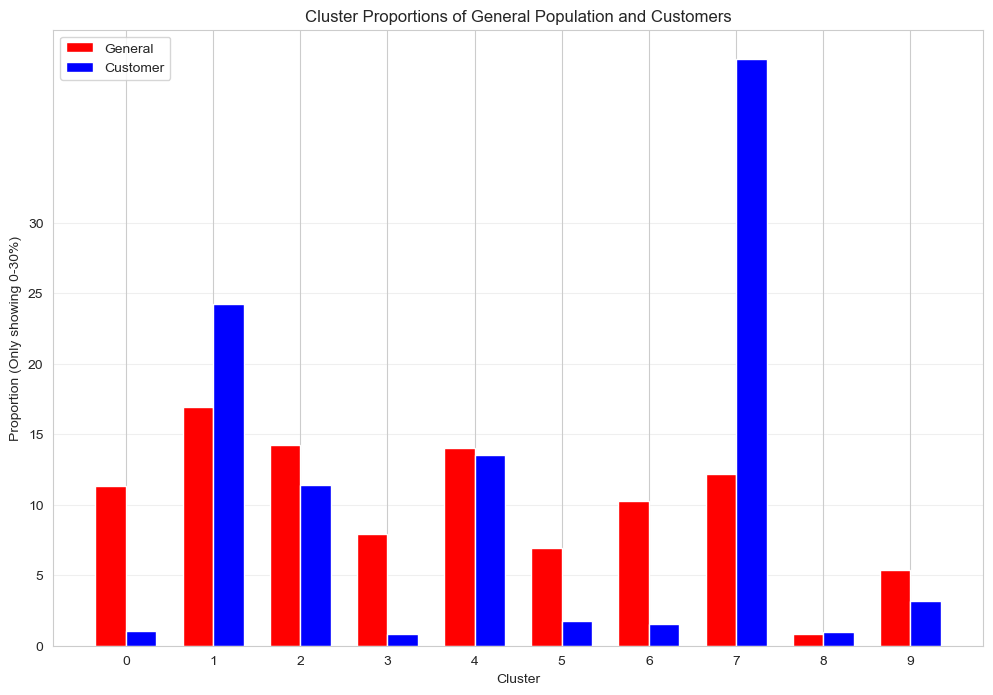

In [26]:
# Plot 1: Proportions of Population and Customers for Each Cluster
width = 0.35
cluster_indexes = np.arange(0, len(np.unique(population_clusters).tolist()))

plt.figure(figsize=(12, 8))
plt.bar(cluster_indexes - width/2, population_proportions * 100, width, color='r', label='General')
plt.bar(cluster_indexes + width/2, customer_proportions * 100, width,  color='b' , label='Customer')

plt.xlabel('Cluster')
plt.ylabel('Proportion (Only showing 0-30%)')

plt.title('Cluster Proportions of General Population and Customers')

plt.xticks(cluster_indexes, np.unique(population_clusters).tolist())
plt.legend(loc='upper left')

plt.yticks(np.arange(0, 31, 5))

plt.grid(True, alpha=0.3, axis='y')

plt.show()

We can also plot the differences between both, to better visualize Over and Under Represented Customers:

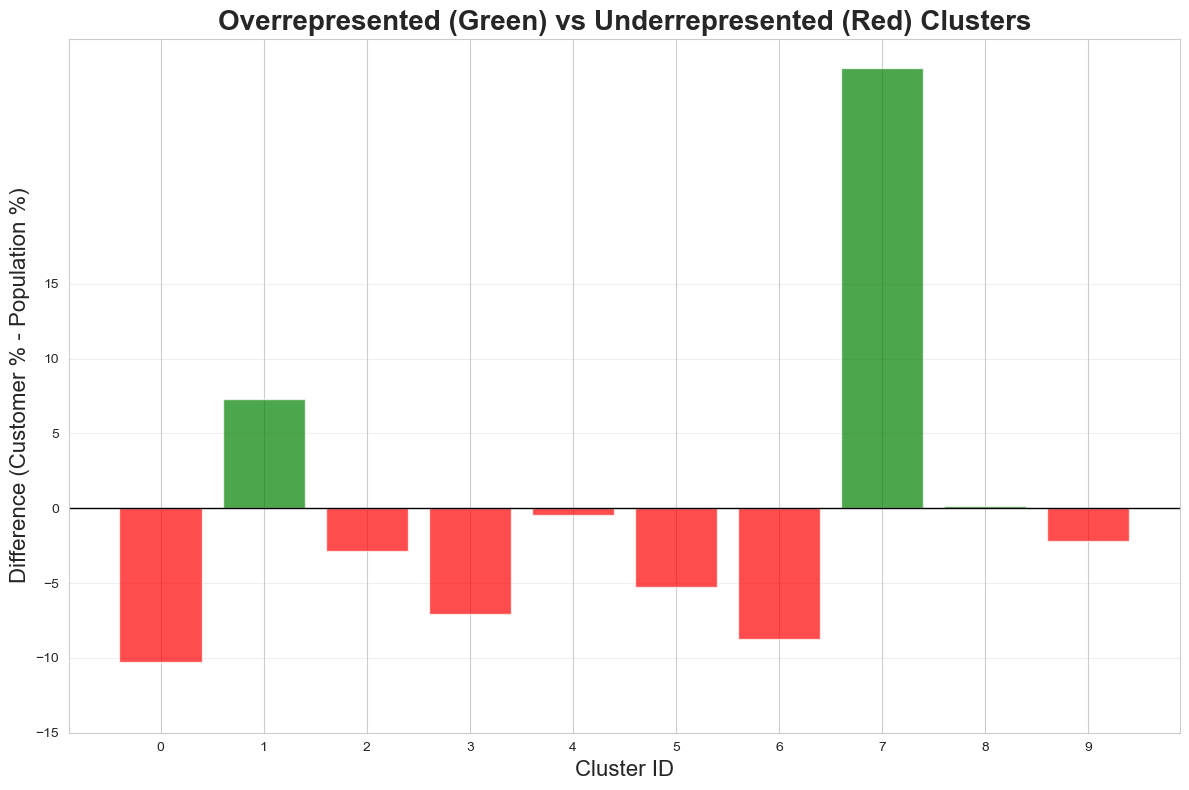

Cluster Analysis:
Cluster 0: Pop=11.31%, Cust=1.04%, Diff=-1027.17% UNDERREPRESENTED
Cluster 1: Pop=16.89%, Cust=24.21%, Diff=+731.70% OVERREPRESENTED
Cluster 2: Pop=14.24%, Cust=11.38%, Diff=-286.07% UNDERREPRESENTED
Cluster 3: Pop=7.91%, Cust=0.81%, Diff=-709.35% UNDERREPRESENTED
Cluster 4: Pop=13.99%, Cust=13.55%, Diff=-44.47% UNDERREPRESENTED
Cluster 5: Pop=6.96%, Cust=1.72%, Diff=-524.14% UNDERREPRESENTED
Cluster 6: Pop=10.27%, Cust=1.51%, Diff=-875.55% UNDERREPRESENTED
Cluster 7: Pop=12.20%, Cust=41.60%, Diff=+2940.45% OVERREPRESENTED
Cluster 8: Pop=0.84%, Cust=0.98%, Diff=+14.27% OVERREPRESENTED
Cluster 9: Pop=5.38%, Cust=3.18%, Diff=-219.68% UNDERREPRESENTED


In [27]:
# Plot 2: Difference (Customer % - Population %)
difference = [c - p for c, p in zip(customer_proportions * 100, population_proportions * 100)]
colors = ['g' if x > 0 else 'r' for x in difference]

# Keep a list of each
over_represented_clusters = []
under_represented_clusters = []

plt.figure(figsize=(12, 8))
plt.bar(cluster_indexes, difference, color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Cluster ID', fontsize=16)
plt.ylabel('Difference (Customer % - Population %)', fontsize=16)
plt.title('Overrepresented (Green) vs Underrepresented (Red) Clusters', fontsize=20, fontweight='bold')

plt.xticks(cluster_indexes)
plt.yticks(np.arange(-15, 16, 5))

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

over_represented_clusters = []

# Print detailed comparison
print("Cluster Analysis:")
print("=" * 70)
for i in cluster_indexes:
    diff = difference[i]

    if diff > 0:
        representation = "OVERREPRESENTED"
        over_represented_clusters.append(int(i))

    else:
        representation = "UNDERREPRESENTED"
        under_represented_clusters.append(int(i))

    print(f"Cluster {i}: Pop={population_proportions[i]:.2%}, "
          f"Cust={customer_proportions[i]:.2%}, "
          f"Diff={diff:+.2%} {representation}")

In [28]:
print(f"Overrepresented clusters: {over_represented_clusters}")
print(f"Underrepresented clusters: {under_represented_clusters}")

Overrepresented clusters: [1, 7, 8]
Underrepresented clusters: [0, 2, 3, 4, 5, 6, 9]


Now that we have the proportions and the clusters for each, we can compare and investigate:

For our comparison and investigation:
- The clusters represent different population segments with similar (hopefully) characteristics
- We have the clusters represented in their reduced form (PCA Components)

Therefore, we can create overrepresented and underrepresented customer profiles by:
1. We use the clusters centroids. The centroids represent the mean value of all points assigned to their respective cluster (which for us is a segment)
2. Transforming the cluster centroids to their original data space using PCA ```inverse_transform()```:
3. Split the data into overrepresented and underrepresented groups (this is scaled data)
4. Invert the scaling using the scaler's ```inverse_transform```
5. We can calculate the weights for each cluster, and that way we can get a weighted data frame for each group
6. Once we have the weighted data for each group, we can filter it by the prominent features identified before
7. Finally, we can combine them both into a single dataframe to easily inspect and compare both groups

At the end, we should get profiles for both groups of customers, with the relevant information to make our analysis.

Step 1: Get the cluster centroids:

In [29]:
# Create a DataFrame for the cluster centers (scaled)
# Step 1: Get the centroids
cluster_centroids = model_final.cluster_centers_

Step 2: Convert Centroids into their Original Data Space:

In [30]:
# Step 2: Get the scaled centroids by using PCA.inverse_transform()
cluster_centroids_scaled = pca_final.inverse_transform(cluster_centroids)
cluster_centroids_scaled

array([[-0.97794773,  0.93269124,  0.42230216, ...,  0.53353114,
         0.72198921,  0.02642284],
       [ 0.62325067, -0.08493964, -0.39440464, ..., -0.13549571,
        -0.32806012, -0.1343321 ],
       [ 0.72726659,  0.90751453,  0.39020412, ..., -0.32190253,
        -0.30746616, -0.03298516],
       ...,
       [ 0.58389676, -0.05219263, -0.44470377, ..., -0.3528146 ,
        -0.32869254, -0.2338699 ],
       [-0.02685375, -0.00995228, -0.0232379 , ..., -0.10060228,
        -0.05773533, -0.07085621],
       [-0.42495008, -0.29227386, -0.44164249, ...,  0.07775548,
        -0.25439249, -0.18553198]], shape=(10, 117))

Step 4: Create Dataframes to Represent Each Group:

In [31]:
# Create the dataframe, using the customer_scaled columns as reference
df_cluster_centroids_scaled = pd.DataFrame(cluster_centroids_scaled, columns=df_customer.columns)
df_cluster_centroids_scaled.head(10)

,ALTERSKATEGORIE_GROB,ANREDE_KZ,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,ANZ_PERSONEN,ANZ_TITEL,ARBEIT,BALLRAUM,CAMEO_DEUG_2015_2,CAMEO_DEUG_2015_3,CAMEO_DEUG_2015_4,CAMEO_DEUG_2015_5,CAMEO_DEUG_2015_6,CAMEO_DEUG_2015_7,CAMEO_DEUG_2015_8,CAMEO_DEUG_2015_9,CAMEO_LIFESTAGE,CAMEO_WEALTH,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,EWDICHTE,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,FINANZ_ANLEGER,FINANZ_HAUSBAUER,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_UNAUFFAELLIGER,FINANZ_VORSORGER,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GEBAEUDETYP_RASTER,GREEN_AVANTGARDE,HEALTH_TYP,HH_EINKOMMEN_SCORE,INNENSTADT,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,KBA13_ANZAHL_PKW,KKK,KONSUMNAEHE,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,MIN_GEBAEUDEJAHR,MOBI_REGIO,NATIONALITAET_KZ_2.0,NATIONALITAET_KZ_3.0,ONLINE_AFFINITAET,ORTSGR_KLS9,OST_WEST_KZ,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_GBZ,PLZ8_HHZ,PRAEGENDE_DECADE,PRAEGENDE_MOVEMENT,REGIOTYP,RELAT_AB,RETOURTYP_BK_S,SEMIO_DOM,SEMIO_ERL,SEMIO_FAM,SEMIO_KAEM,SEMIO_KRIT,SEMIO_KULT,SEMIO_LUST,SEMIO_MAT,SEMIO_PFLICHT,SEMIO_RAT,SEMIO_REL,SEMIO_SOZ,SEMIO_TRADV,SEMIO_VERT,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SOHO_KZ,VERS_TYP,WOHNDAUER_2008,W_KEIT_KIND_HH,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,-0.977948,0.932691,0.422302,0.058846,-0.231309,-0.030509,0.472763,-0.385536,-0.315773,-0.287222,-0.319975,-0.043698,-0.042547,0.136424,0.378059,0.500255,-0.552723,0.742473,-0.221904,0.085389,-0.057252,0.242613,0.240074,0.697781,-0.352183,-0.249618,-0.034989,-0.345926,-0.448257,0.980399,0.850113,-1.409193,1.131121,0.780368,-0.880957,-0.067784,0.217744,-0.025661,-0.001393,-0.018847,0.175735,-0.369862,-0.453964,0.139699,0.788877,-0.556054,-0.717816,0.053576,0.539116,0.506342,-0.740025,-0.263828,0.159313,-0.588294,-0.112681,-0.134526,-0.133455,0.113271,0.141905,0.044386,0.012905,-0.023282,-0.075909,0.005913,-0.388684,1.477837,-0.230258,-0.338714,-0.228220,-0.140096,-0.084795,-0.147907,-0.452541,-0.219289,-0.753850,0.184355,0.303225,0.116962,0.704393,-0.141611,-0.756619,0.535797,0.777888,0.753764,-0.551757,0.166602,0.908599,0.453964,0.226011,0.438715,-0.535332,0.852981,-0.121428,-0.100125,0.967205,0.527183,-0.032565,-0.484252,0.459428,1.013650,1.265810,0.689115,-0.471731,0.947628,-1.034426,-0.020504,0.413090,-0.191201,-0.094007,0.028324,-0.319061,-0.022261,-0.169511,-0.533384,0.533531,0.721989,0.026423
1,0.623251,-0.084940,-0.394405,-0.107532,0.105552,-0.044630,-0.530257,0.583601,0.185600,0.314241,0.364525,0.039456,-0.005322,-0.105126,-0.340868,-0.353743,0.297904,-0.570528,0.449373,-0.078960,-0.166220,-0.071275,-0.250395,-0.936869,0.562021,-0.197598,-0.249050,-0.229776,0.510378,-0.293204,-0.463569,0.883869,-0.745091,-0.673670,0.662456,0.136785,-0.250521,0.033103,-0.001074,0.027204,-0.172254,0.378537,-0.551793,-0.036167,-0.351668,0.725915,0.710288,-0.152292,-0.509036,-0.447228,0.770399,0.099071,0.208106,0.664583,0.084448,0.071451,0.134594,-0.057915,-0.059545,-0.039429,-0.080934,-0.049436,0.005792,-0.013815,-0.319701,-0.429659,-0.181957,0.121337,-0.213366,0.052396,-0.036114,0.070368,1.204230,0.156734,0.785088,-0.200862,-0.140527,-0.107556,-0.918801,-0.005568,0.739501,-0.639849,-0.850593,-0.757586,0.405186,-0.365626,-0.627877,0.551793,0.076550,-0.551483,0.093859,-0.191435,0.388502,-0.324019,-0.187407,0.015804,-0.289394,0.274625,-0.471321,-0.547619,-0.521618,-0.531286,-0.206568,-0.538030,0.137304,-0.060932,-0.078576,0.063615,-0.091919,-0.115107,0.239646,0.073595,-0.064288,0.336656,-0.135496,-0.328060,-0.134332
2,0.727267,0.907515,0.390204,0.15036

We have the centroids, now let's split it into the two groups:

In [32]:
# Create the dataframes for the (centroid) overrepresented and underrepresented customers (scaled)
overrep_scaled = df_cluster_centroids_scaled.iloc[over_represented_clusters]
underrep_scaled = df_cluster_centroids_scaled.iloc[under_represented_clusters]

# We get nparrays in return, convert to DataFrame
df_overrep_scaled = pd.DataFrame(overrep_scaled, columns=df_customer.columns)
df_underrep_scaled = pd.DataFrame(underrep_scaled, columns=df_customer.columns)

In [33]:
df_overrep_scaled.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,ANZ_PERSONEN,ANZ_TITEL,ARBEIT,BALLRAUM,CAMEO_DEUG_2015_2,CAMEO_DEUG_2015_3,CAMEO_DEUG_2015_4,CAMEO_DEUG_2015_5,CAMEO_DEUG_2015_6,CAMEO_DEUG_2015_7,CAMEO_DEUG_2015_8,CAMEO_DEUG_2015_9,CAMEO_LIFESTAGE,CAMEO_WEALTH,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,EWDICHTE,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,FINANZ_ANLEGER,FINANZ_HAUSBAUER,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_UNAUFFAELLIGER,FINANZ_VORSORGER,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GEBAEUDETYP_RASTER,GREEN_AVANTGARDE,HEALTH_TYP,HH_EINKOMMEN_SCORE,INNENSTADT,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,KBA13_ANZAHL_PKW,KKK,KONSUMNAEHE,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,MIN_GEBAEUDEJAHR,MOBI_REGIO,NATIONALITAET_KZ_2.0,NATIONALITAET_KZ_3.0,ONLINE_AFFINITAET,ORTSGR_KLS9,OST_WEST_KZ,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_GBZ,PLZ8_HHZ,PRAEGENDE_DECADE,PRAEGENDE_MOVEMENT,REGIOTYP,RELAT_AB,RETOURTYP_BK_S,SEMIO_DOM,SEMIO_ERL,SEMIO_FAM,SEMIO_KAEM,SEMIO_KRIT,SEMIO_KULT,SEMIO_LUST,SEMIO_MAT,SEMIO_PFLICHT,SEMIO_RAT,SEMIO_REL,SEMIO_SOZ,SEMIO_TRADV,SEMIO_VERT,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SOHO_KZ,VERS_TYP,WOHNDAUER_2008,W_KEIT_KIND_HH,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
1,0.623251,-0.084940,-0.394405,-0.107532,0.105552,-0.044630,-0.530257,0.583601,0.185600,0.314241,0.364525,0.039456,-0.005322,-0.105126,-0.340868,-0.353743,0.297904,-0.570528,0.449373,-0.078960,-0.166220,-0.071275,-0.250395,-0.936869,0.562021,-0.197598,-0.249050,-0.229776,0.510378,-0.293204,-0.463569,0.883869,-0.745091,-0.673670,0.662456,0.136785,-0.250521,0.033103,-0.001074,0.027204,-0.172254,0.378537,-0.551793,-0.036167,-0.351668,0.725915,0.710288,-0.152292,-0.509036,-0.447228,0.770399,0.099071,0.208106,0.664583,0.084448,0.071451,0.134594,-0.057915,-0.059545,-0.039429,-0.080934,-0.049436,0.005792,-0.013815,-0.319701,-0.429659,-0.181957,0.121337,-0.213366,0.052396,-0.036114,0.070368,1.204230,0.156734,0.785088,-0.200862,-0.140527,-0.107556,-0.918801,-0.005568,0.739501,-0.639849,-0.850593,-0.757586,0.405186,-0.365626,-0.627877,0.551793,0.076550,-0.551483,0.093859,-0.191435,0.388502,-0.324019,-0.187407,0.015804,-0.289394,0.274625,-0.471321,-0.547619,-0.521618,-0.531286,-0.206568,-0.538030,0.137304,-0.060932,-0.078576,0.063615,-0.091919,-0.115107,0.239646,0.073595,-0.064288,0.336656,-0.135496,-0.328060,-0.134332
7,0.583897,-0.052193,-0.444704,-0.068200,0.432450,0.126576,-0.199067,-0.011019,0.576799,0.146159,0.152534,-0.014857,-0.104882,-0.205313,-0.379304,-0.373381,0.506195,-0.866675,0.248860,-0.049553,-0.145085,-0.067557,-0.036413,-0.024779,0.480864,-0.152572,-0.191386,0.301184,0.162587,-0.751782,-0.651187,1.093799,-0.818738,-0.497470,0.699260,0.055510,-0.252269,0.027630,-0.001002,0.005473,-0.162520,0.295194,1.875350,-0.161433,-1.345157,0.067410,0.977585,-0.146365,-0.556867,-0.454323,0.765916,0.197633,-0.564071,0.282395,0.222331,0.237750,0.212333,-0.058092,-0.055201,-0.004834,-0.063767,0.018106,0.158177,0.020839,1.918264,-0.392412,-0.157064,-0.313201,-0.193946,0.114546,0.192136,-0.100435,-0.399717,-0.092179,0.911593,-0.210210,-0.148101,0.296699,-0.024249,0.266342,0.617917,-0.313521,-0.478298,-0.454535,0.499685,0.073435,-0.653771,-1.875350,-0.555887,-0.153134,0.258141,0.079629,0.317165,-0.362889,-0.040050,-0.099971,-0.333912,0.465046,-0.412914,-0.572348,-0.465379,-0.562987,-0.076774,-0.396833,0.210344,-0.188385,-0.135854,0.301888,-0.091859,-0.079724,0.349970,-0.085776,0.339014,0.015891,-0.352815,-0.328693,-0.233870
8,-0.026854,-0.009952,-0.023

In [34]:
df_underrep_scaled.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,ANZ_PERSONEN,ANZ_TITEL,ARBEIT,BALLRAUM,CAMEO_DEUG_2015_2,CAMEO_DEUG_2015_3,CAMEO_DEUG_2015_4,CAMEO_DEUG_2015_5,CAMEO_DEUG_2015_6,CAMEO_DEUG_2015_7,CAMEO_DEUG_2015_8,CAMEO_DEUG_2015_9,CAMEO_LIFESTAGE,CAMEO_WEALTH,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,EWDICHTE,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,FINANZ_ANLEGER,FINANZ_HAUSBAUER,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_UNAUFFAELLIGER,FINANZ_VORSORGER,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GEBAEUDETYP_RASTER,GREEN_AVANTGARDE,HEALTH_TYP,HH_EINKOMMEN_SCORE,INNENSTADT,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,KBA13_ANZAHL_PKW,KKK,KONSUMNAEHE,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,MIN_GEBAEUDEJAHR,MOBI_REGIO,NATIONALITAET_KZ_2.0,NATIONALITAET_KZ_3.0,ONLINE_AFFINITAET,ORTSGR_KLS9,OST_WEST_KZ,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_GBZ,PLZ8_HHZ,PRAEGENDE_DECADE,PRAEGENDE_MOVEMENT,REGIOTYP,RELAT_AB,RETOURTYP_BK_S,SEMIO_DOM,SEMIO_ERL,SEMIO_FAM,SEMIO_KAEM,SEMIO_KRIT,SEMIO_KULT,SEMIO_LUST,SEMIO_MAT,SEMIO_PFLICHT,SEMIO_RAT,SEMIO_REL,SEMIO_SOZ,SEMIO_TRADV,SEMIO_VERT,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SOHO_KZ,VERS_TYP,WOHNDAUER_2008,W_KEIT_KIND_HH,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,-0.977948,0.932691,0.422302,0.058846,-0.231309,-0.030509,0.472763,-0.385536,-0.315773,-0.287222,-0.319975,-0.043698,-0.042547,0.136424,0.378059,0.500255,-0.552723,0.742473,-0.221904,0.085389,-0.057252,0.242613,0.240074,0.697781,-0.352183,-0.249618,-0.034989,-0.345926,-0.448257,0.980399,0.850113,-1.409193,1.131121,0.780368,-0.880957,-0.067784,0.217744,-0.025661,-0.001393,-0.018847,0.175735,-0.369862,-0.453964,0.139699,0.788877,-0.556054,-0.717816,0.053576,0.539116,0.506342,-0.740025,-0.263828,0.159313,-0.588294,-0.112681,-0.134526,-0.133455,0.113271,0.141905,0.044386,0.012905,-0.023282,-0.075909,0.005913,-0.388684,1.477837,-0.230258,-0.338714,-0.228220,-0.140096,-0.084795,-0.147907,-0.452541,-0.219289,-0.753850,0.184355,0.303225,0.116962,0.704393,-0.141611,-0.756619,0.535797,0.777888,0.753764,-0.551757,0.166602,0.908599,0.453964,0.226011,0.438715,-0.535332,0.852981,-0.121428,-0.100125,0.967205,0.527183,-0.032565,-0.484252,0.459428,1.013650,1.265810,0.689115,-0.471731,0.947628,-1.034426,-0.020504,0.413090,-0.191201,-0.094007,0.028324,-0.319061,-0.022261,-0.169511,-0.533384,0.533531,0.721989,0.026423
2,0.727267,0.907515,0.390204,0.150364,-0.295860,-0.005527,0.364854,-0.279880,-0.289530,-0.218791,-0.284552,-0.019508,0.124003,0.151477,0.345082,0.185489,-0.080948,0.588109,0.333704,-0.134217,-0.064018,-0.128618,-0.232065,0.493932,0.207081,-0.260785,-0.288550,0.057990,0.271348,-0.443412,0.782414,-0.312735,-0.606755,-0.670819,0.636758,-0.064559,0.189116,-0.022397,-0.001086,-0.015701,0.105537,-0.255696,-0.339618,-0.321182,0.624317,-0.380057,-0.642120,0.128351,0.472981,0.414736,-0.681263,-0.131914,0.072290,-0.428756,-0.111479,-0.171310,-0.002976,-0.063219,-0.069431,-0.027578,-0.098143,-0.135309,-0.121431,-0.034780,-0.369397,-0.209892,0.315074,0.102659,-0.146742,-0.080306,-0.020539,-0.102379,-0.342233,-0.227408,-0.657677,-0.184937,-0.114161,-0.697169,0.468227,-0.130638,-0.568231,0.445559,0.589550,0.532680,-0.377889,0.146643,-0.687371,0.339618,0.093451,0.369781,0.525214,0.689415,1.041177,-0.999959,0.947893,0.814086,-1.154171,0.434785,-0.676361,-0.668633,-0.291999,-1.002482,-0.607971,-0.774534,-0.802374,-0.163090,0.084028,0.449836,-0.092299,0.203956,0.080049,0.329641,-0.182698,1.047878,-0.321903,-0.307466,-0.032985
3,-0.841404,-1.108151,0.538748,0.069

Step 5: Invert the Scaling:

Now that we have the two groups split, we need to inverse the scaling to get visually important information (so we can compare to the data dictionary codes).

In [35]:
# Inverse scaling

# Inverse transform, get back nparrays
overrep = scaler.inverse_transform(df_overrep_scaled)
underrep = scaler.inverse_transform(df_underrep_scaled)

# We get nparrays in return, convert to DataFrame
df_overrep = pd.DataFrame(overrep, columns=df_customer.columns)
df_underrep = pd.DataFrame(underrep, columns=df_customer.columns)

# Set the proper index
df_overrep.index = over_represented_clusters
df_underrep.index = under_represented_clusters

Step 6: Create Weighted Dataframes, so that we can summarize the data and not have to look at each cluster individually:

First we get the cluster weights for each group:

In [36]:
# Get the cluster weights
cluster_weights_over = customer_proportions[df_overrep.index]
cluster_weights_under = customer_proportions[df_underrep.index]

# Normalize them
cluster_weights_over_normalized = cluster_weights_over / cluster_weights_over.sum()
cluster_weights_under_normalized = cluster_weights_under / cluster_weights_under.sum()

print(cluster_weights_over_normalized)
print(cluster_weights_under_normalized)

1    0.362452
7    0.622811
8    0.014737
Name: proportion, dtype: float64
0    0.031325
2    0.342812
3    0.024524
4    0.408076
5    0.051812
6    0.045564
9    0.095888
Name: proportion, dtype: float64


We do not care about ALL the features, so we will filter them out and just focus on the prominent features we identified before

In [37]:
# Now we get a list of the prominent features, as identified in Step 1.4.5
prominent_features_list = [
    (feature, pc_no, "+" if weight > 0 else "-")
    for pc_no, feature_dict in prominent_features.items()
    for feature, weight in feature_dict.items()
]
print(prominent_features_list)

[('FINANZ_MINIMALIST', 0, '+'), ('MOBI_REGIO', 0, '+'), ('PLZ8_ANTG1', 0, '+'), ('KBA05_ANTG1', 0, '+'), ('KBA05_GBZ', 0, '+'), ('ORTSGR_KLS9', 0, '-'), ('PLZ8_ANTG4', 0, '-'), ('HH_EINKOMMEN_SCORE', 0, '-'), ('CAMEO_WEALTH', 0, '-'), ('PLZ8_ANTG3', 0, '-'), ('ALTERSKATEGORIE_GROB', 1, '+'), ('FINANZ_VORSORGER', 1, '+'), ('ZABEOTYP_3', 1, '+'), ('SEMIO_ERL', 1, '+'), ('SEMIO_LUST', 1, '+'), ('SEMIO_TRADV', 1, '-'), ('FINANZ_SPARER', 1, '-'), ('SEMIO_REL', 1, '-'), ('FINANZ_UNAUFFAELLIGER', 1, '-'), ('PRAEGENDE_DECADE', 1, '-'), ('ANREDE_KZ', 2, '+'), ('SEMIO_KAEM', 2, '+'), ('SEMIO_DOM', 2, '+'), ('SEMIO_KRIT', 2, '+'), ('SEMIO_ERL', 2, '+'), ('FINANZTYP_5', 2, '-'), ('SEMIO_KULT', 2, '-'), ('SEMIO_SOZ', 2, '-'), ('SEMIO_FAM', 2, '-'), ('SEMIO_VERT', 2, '-')]


Now that we have the cluster weights (normalized) and the prominent features, we create separate weighted profiles for each group:

In [45]:
# Create unique labels first (feature + PC + sign)
labels = [f"{feature}-PC{pc+1}({sign})" for feature, pc, sign in prominent_features_list]

# Get weighted values for each feature (allowing duplicates since labels are unique)
over_values = [(df_overrep[feature] * cluster_weights_over_normalized).sum()
               for feature, pc, sign in prominent_features_list]
under_values = [(df_underrep[feature] * cluster_weights_under_normalized).sum()
                for feature, pc, sign in prominent_features_list]

# Create Series with unique labels
df_weighted_avg_profile_over = pd.Series(over_values, index=labels)
df_weighted_avg_profile_under = pd.Series(under_values, index=labels)

We can now neatly visualize the profiles for both groups:

In [46]:
df_weighted_avg_profile_over

FINANZ_MINIMALIST-PC1(+)           4.439454
MOBI_REGIO-PC1(+)                  4.107949
PLZ8_ANTG1-PC1(+)                  2.872695
KBA05_ANTG1-PC1(+)                 2.638825
KBA05_GBZ-PC1(+)                   4.131831
ORTSGR_KLS9-PC1(-)                 4.491155
PLZ8_ANTG4-PC1(-)                  0.273514
HH_EINKOMMEN_SCORE-PC1(-)          2.921659
CAMEO_WEALTH-PC1(-)                2.178908
PLZ8_ANTG3-PC1(-)                  1.015795
ALTERSKATEGORIE_GROB-PC2(+)        3.395122
FINANZ_VORSORGER-PC2(+)            4.363179
ZABEOTYP_3-PC2(+)                  0.416144
SEMIO_ERL-PC2(+)                   5.239539
SEMIO_LUST-PC2(+)                  5.153192
SEMIO_TRADV-PC2(-)                 2.943222
FINANZ_SPARER-PC2(-)               1.557739
SEMIO_REL-PC2(-)                   2.957965
FINANZ_UNAUFFAELLIGER-PC2(-)       1.883394
PRAEGENDE_DECADE-PC2(-)         1964.630513
ANREDE_KZ-PC3(+)                   1.489785
SEMIO_KAEM-PC3(+)                  4.119987
SEMIO_DOM-PC3(+)                

In [47]:
df_weighted_avg_profile_under

FINANZ_MINIMALIST-PC1(+)           2.980976
MOBI_REGIO-PC1(+)                  2.165598
PLZ8_ANTG1-PC1(+)                  1.861922
KBA05_ANTG1-PC1(+)                 0.752920
KBA05_GBZ-PC1(+)                   2.565582
ORTSGR_KLS9-PC1(-)                 6.039423
PLZ8_ANTG4-PC1(-)                  0.941465
HH_EINKOMMEN_SCORE-PC1(-)          4.975859
CAMEO_WEALTH-PC1(-)                3.858593
PLZ8_ANTG3-PC1(-)                  2.002442
ALTERSKATEGORIE_GROB-PC2(+)        3.071822
FINANZ_VORSORGER-PC2(+)            3.768153
ZABEOTYP_3-PC2(+)                  0.521045
SEMIO_ERL-PC2(+)                   4.856980
SEMIO_LUST-PC2(+)                  4.682386
SEMIO_TRADV-PC2(-)                 3.216639
FINANZ_SPARER-PC2(-)               2.361248
SEMIO_REL-PC2(-)                   3.608052
FINANZ_UNAUFFAELLIGER-PC2(-)       2.287052
PRAEGENDE_DECADE-PC2(-)         1970.010792
ANREDE_KZ-PC3(+)                   1.466423
SEMIO_KAEM-PC3(+)                  4.249105
SEMIO_DOM-PC3(+)                

In [48]:
# How much data did we not consider?


In [51]:
# combine them:
# Combine them
df_profile = pd.DataFrame({
    'overrepresented': df_weighted_avg_profile_over,
    'underrepresented': df_weighted_avg_profile_under
}).round()
df_profile.head()

,overrepresented,underrepresented
FINANZ_MINIMALIST-PC1(+),4.0,3.0
MOBI_REGIO-PC1(+),4.0,2.0
PLZ8_ANTG1-PC1(+),3.0,2.0
KBA05_ANTG1-PC1(+),3.0,1.0
KBA05_GBZ-PC1(+),4.0,3.0


Last, but not least, we have to remember that the prominent features were 5 positive and 5 negative for each PC, so for convenience, we re-order the rows by their PC number and sign, so first we show features from PC1 and positives, PC2 and positives, PC3 and positives, and then PC1 and negatives, PC2 and negatives and lastly, PC3 and negatives:

In [52]:
# Define sign ordering for sorting
sign_rank = {"+": 0, "-": 1}

order = {
    f"{feature}-PC{pc+1}({sign})": (sign_rank[sign], pc)
    for feature, pc, sign in prominent_features_list
}

df_profile_sorted = df_profile.loc[sorted(df_profile.index, key=lambda x: order[x])]

In [53]:
# Visualize the sorted DataFrame
df_profile_sorted

,overrepresented,underrepresented
FINANZ_MINIMALIST-PC1(+),4.0,3.0
MOBI_REGIO-PC1(+),4.0,2.0
PLZ8_ANTG1-PC1(+),3.0,2.0
KBA05_ANTG1-PC1(+),3.0,1.0
KBA05_GBZ-PC1(+),4.0,3.0
ALTERSKATEGORIE_GROB-PC2(+),3.0,3.0
FINANZ_VORSORGER-PC2(+),4.0,4.0
ZABEOTYP_3-PC2(+),0.0,1.0
SEMIO_ERL-PC2(+),5.0,5.0
SEMIO_LUST-PC2(+),5.0,5.0


In [54]:
print(df_profile_sorted)

                              overrepresented  underrepresented
FINANZ_MINIMALIST-PC1(+)                  4.0               3.0
MOBI_REGIO-PC1(+)                         4.0               2.0
PLZ8_ANTG1-PC1(+)                         3.0               2.0
KBA05_ANTG1-PC1(+)                        3.0               1.0
KBA05_GBZ-PC1(+)                          4.0               3.0
ALTERSKATEGORIE_GROB-PC2(+)               3.0               3.0
FINANZ_VORSORGER-PC2(+)                   4.0               4.0
ZABEOTYP_3-PC2(+)                         0.0               1.0
SEMIO_ERL-PC2(+)                          5.0               5.0
SEMIO_LUST-PC2(+)                         5.0               5.0
ANREDE_KZ-PC3(+)                          1.0               1.0
SEMIO_KAEM-PC3(+)                         4.0               4.0
SEMIO_DOM-PC3(+)                          5.0               4.0
SEMIO_KRIT-PC3(+)                         4.0               5.0
SEMIO_ERL-PC3(+)                        

We now have a very clear profile of each group! We use this in Discussion 3.3.

# Customer Segment Interpretation

## Overrepresented Customers (Target Audience)

### PC1 - Wealth & Geography

| Feature | Over | Under | Interpretation |
|---------|------|-------|----------------|
| CAMEO_WEALTH | 2 | 4 | **Wealthier** (1=rich, 5=poor) |
| HH_EINKOMMEN_SCORE | 3 | 5 | **Higher income** (1=highest) |
| ORTSGR_KLS9 | 4 | 6 | **Smaller towns** (1=<2k, 9=>500k) |
| PLZ8_ANTG1 | 3 | 2 | More 1-2 family homes in area |
| KBA05_ANTG1 | 3 | 1 | More single-family home neighborhoods |
| MOBI_REGIO | 4 | 2 | **Lower mobility** (more rural/stable) |

### PC2 - Age & Financial Mindset

| Feature | Over | Under | Interpretation |
|---------|------|-------|----------------|
| PRAEGENDE_DECADE | 1965 | 1970 | **Older generation** (formative years in 60s) |
| FINANZ_SPARER | 2 | 2 | Strong money-savers (1=very high) |
| SEMIO_REL | 3 | 4 | Slightly less religious |

### PC3 - Gender & Personality

| Feature | Over | Under | Interpretation |
|---------|------|-------|----------------|
| ANREDE_KZ | 1 | 1 | **Male** (1=male, 2=female) |
| SEMIO_DOM | 5 | 4 | More dominant personality |
| SEMIO_FAM | 3 | 4 | **Less family-oriented** |
| SEMIO_VERT | 5 | 4 | More dreamful/imaginative |

---

## Summary Profile

**Target customers are:**

- **Wealthy, high-income individuals** living in smaller towns/rural areas
- **Older males** (formative years in the 1960s)
- Living in **stable, single-family home neighborhoods** with low mobility
- **Strong money-savers** but less family-oriented
- **Dominant, dreamful personality** types

**Underrepresented (non-target) customers are:**

- Lower income, living in larger cities
- Slightly younger generation (1970s)
- More family-oriented
- Higher residential mobility (urban apartment dwellers)

---

## Conclusion

This suggests the mail-order company appeals most to **established, affluent older men in suburban/rural Germany** who value financial security and have a traditional but independent lifestyle.

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.